In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('kenya_property24_sales.csv')
df

,Title,Detail URL,Location,Bedrooms,Bathrooms,House Size,Price,Property Type,Listing Date,Amenities
0,3 Bedroom Apartment / Flat,https://www.property24.co.ke/3-bedroom-apartme...,Westlands,3.0,4.5,155 m²,KSh 24 600 000,Apartment / Flat,20-Feb-26,"400 m² Fully Equipped Gym, 1.7-Acre Shopping M..."
1,1 Bedroom Apartment / Flat,https://www.property24.co.ke/1-bedroom-apartme...,Westlands,1.0,1.0,65 m²,KSh 6 500 000,Apartment / Flat,18-Feb-26,NaN
2,2 Bedroom Apartment / Flat,https://www.property24.co.ke/2-bedroom-apartme...,Kilimani,2.0,2.0,110 m²,KSh 11 800 000,Apartment / Flat,16-Feb-26,Plumeria Residency is located at the intersect...
3,2 Bedroom Apartment / Flat,https://www.property24.co.ke/2-bedroom-apartme...,Riverside,2.0,2.0,114 m²,KSh 13 600 000,Apartment / Flat,16-Feb-26,"1 Bedroom (60–81?) – From KSh 7.2M to 10.92M, ..."
4,3 Bedroom Apartment / Flat,https://www.property24.co.ke/3-bedroom-apartme...,Westlands,3.0,3.0,155 m²,KSh 21 714 000,Apartment / Flat,16-Feb-26,NaN
...,...,...,...,...,...,...,...,...,...,...
445,1 Bedroom Apartment / Flat,https://www.property24.co.ke/1-bedroom-apartme...,Westlands,1.0,1.0,46 m²,KSh 8 500 000,Apartment / Flat,09-Nov-25,"Rooftop swimming pool, Fully equipped rooftop ..."
446,4 Bedroom Townhouse,https://www.property24.co.ke/4-bedroom-townhou...,Karen,4.0,5.0,4 m²,KSh 105 000 000,Townhouse,27-Nov-25,NaN
447,4 Bedroom Apartment / Flat,https://www.property24.co.ke/4-bedroom-apartme...,Westlands,4.0,5.0,172 m²,KSh 31 000 000,Apartment / Flat,10-Nov-25,NaN
448,1 Bedroom Apartment / Flat,https://www.property24.co.ke/1-bedroom-apartme...,Westlands,1.0,1.0,4 m²,KSh 4 200 000,Apartment / Flat,06-Feb-26,"• Perfect for families, executives & investors"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          450 non-null    object 
 1   Detail URL     450 non-null    object 
 2   Location       450 non-null    object 
 3   Bedrooms       450 non-null    float64
 4   Bathrooms      450 non-null    float64
 5   House Size     450 non-null    object 
 6   Price          450 non-null    object 
 7   Property Type  450 non-null    object 
 8   Listing Date   450 non-null    object 
 9   Amenities      188 non-null    object 
dtypes: float64(2), object(8)
memory usage: 35.3+ KB


In [4]:
df.describe()

,Bedrooms,Bathrooms
count,450.000000,450.000000
mean,2.610000,2.757778
std,1.415241,1.650806
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,4.000000,4.000000
max,9.000000,9.500000


In [5]:
# Data Cleaning and Preprocessing

df = df.drop_duplicates()



In [6]:
# issing Values
df.isnull().sum()   

Title              0
Detail URL         0
Location           0
Bedrooms           0
Bathrooms          0
House Size         0
Price              0
Property Type      0
Listing Date       0
Amenities        262
dtype: int64

In [7]:
## Amenities has a lot of missing values,  but it is essential for our model, so we will fill the missing values with 'None'
df['Amenities'] = df['Amenities'].fillna('None')
df['Amenities']

0      400 m² Fully Equipped Gym, 1.7-Acre Shopping M...
1                                                   None
2      Plumeria Residency is located at the intersect...
3      1 Bedroom (60–81?) – From KSh 7.2M to 10.92M, ...
4                                                   None
                             ...                        
445    Rooftop swimming pool, Fully equipped rooftop ...
446                                                 None
447                                                 None
448       • Perfect for families, executives & investors
449    Secure & Comfortable Living – CCTV, backup pow...
Name: Amenities, Length: 450, dtype: object

In [8]:
# standardize locations names
df["Location"] = (
    df["Location"]
    .str.lower()
    .str.strip()
    .str.replace("nairobi", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Location"].unique()

array(['westlands', 'kilimani', 'riverside', 'lavington', 'mirema',
       'kileleshwa', 'peponi', 'syokimau', 'runda', 'muthaiga',
       'industrial area', 'upper hill', 'karen', 'parklands', 'uthiru',
       'lower kabete', 'kyuna', 'embakasi', 'kiambu road', 'ridgeways',
       'loresho', 'kitisuru', 'langata', 'donholm', 'rhapta road',
       'gigiri', 'dagoretti', 'kasarani', 'south c', 'nyari', 'riruta',
       'mountain view', ' cbd', 'spring valley'], dtype=object)

In [9]:
df.dtypes

Title             object
Detail URL        object
Location          object
Bedrooms         float64
Bathrooms        float64
House Size        object
Price             object
Property Type     object
Listing Date      object
Amenities         object
dtype: object

In [10]:
# convert listing date to datetime
df["Listing Date"] = pd.to_datetime(df["Listing Date"], errors="coerce")


C:\Users\Cameline\AppData\Local\Temp\ipykernel_14804\1721405815.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Listing Date"] = pd.to_datetime(df["Listing Date"], errors="coerce")


In [11]:
# converting price to numeric
df["Price"] = (
    df["Price"]
    .str.replace("KSh", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [12]:
df.dtypes

Title                    object
Detail URL               object
Location                 object
Bedrooms                float64
Bathrooms               float64
House Size               object
Price                     int64
Property Type            object
Listing Date     datetime64[ns]
Amenities                object
dtype: object

In [13]:
# standardizing the unit of area to square feet

df["House Size"] = df["House Size"].str.replace(",", "", regex=False)

# Extract numeric value
df["size_value"] = df["House Size"].str.extract(r"(\d+\.?\d*)").astype(float)

# Extract unit (m², acres, etc.)
df["size_unit"] = df["House Size"].str.extract(r"(m²|acres|sqm|sqft)")

df["size_sqft"] = df["size_value"]

# Convert m² → sqft
df.loc[df["size_unit"].isin(["m²", "sqm"]), "size_sqft"] *= 10.7639

# Convert acres → sqft
df.loc[df["size_unit"] == "acres", "size_sqft"] *= 43560


df["size_sqft"] = df["size_sqft"].round(2)


In [14]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df["Price"] >= lower_bound) & (df["Price"] <= upper_bound)]

In [15]:
# drop the url column
df = df.drop(columns=["Detail URL"])

In [16]:
df

,Title,Location,Bedrooms,Bathrooms,House Size,Price,Property Type,Listing Date,Amenities,size_value,size_unit,size_sqft
0,3 Bedroom Apartment / Flat,westlands,3.0,4.5,155 m²,24600000,Apartment / Flat,2026-02-20,"400 m² Fully Equipped Gym, 1.7-Acre Shopping M...",155.0,m²,1668.40
1,1 Bedroom Apartment / Flat,westlands,1.0,1.0,65 m²,6500000,Apartment / Flat,2026-02-18,None,65.0,m²,699.65
2,2 Bedroom Apartment / Flat,kilimani,2.0,2.0,110 m²,11800000,Apartment / Flat,2026-02-16,Plumeria Residency is located at the intersect...,110.0,m²,1184.03
3,2 Bedroom Apartment / Flat,riverside,2.0,2.0,114 m²,13600000,Apartment / Flat,2026-02-16,"1 Bedroom (60–81?) – From KSh 7.2M to 10.92M, ...",114.0,m²,1227.08
4,3 Bedroom Apartment / Flat,westlands,3.0,3.0,155 m²,21714000,Apartment / Flat,2026-02-16,None,155.0,m²,1668.40
...,...,...,...,...,...,...,...,...,...,...,...,...
444,2 Bedroom Apartment / Flat,kilimani,2.0,2.0,120 m²,10500000,Apartment / Flat,2026-02-09,"Yaya Centre – 5 mins, Adams Arcade – 6 mins, P...",120.0,m²,1291.67
445,1 Bedroom Apartment / Flat,westlands,1.0,1.0,46 m²,8500000,Apartment / Flat,2025-11-09,"Rooftop swimming pool, Fully equipped rooftop ...",46.0,m²,495.14
447,4 Bedroom Apartment / Flat,westlands,4.0,5.0,172 m²,31000000,Apartment / Flat,2025-11-10,None,172.0,m²,1851.39
448,1 Bedroom Apartment / Flat,westlands,1.0,1.0,4 m²,4200000,Apartment / Flat,2026-02-06,"• Perfect for families, executives & investors",4.0,m²,43.06


In [17]:
# cleaning the amenities column
df["Amenities"] = df["Amenities"].str.lower().str.strip()
# Remove everything except letters, numbers, spaces, and commas
df["Amenities"] = df["Amenities"].str.replace(r"[^a-zA-Z0-9\s,]" ,"", regex=True)

# Convert to lowercase and strip leading/trailing spaces
df["Amenities"] = df["Amenities"].str.lower().str.strip()

# Optional: remove extra spaces around commas
df["Amenities"] = df["Amenities"].str.replace(r"\s*,\s*", ", ", regex=True)

# Check unique cleaned amenities
print(df["Amenities"].unique())


['400 m fully equipped gym, 17acre shopping mall, heated indoor  outdoor swimming pool, indoor  outdoor kids playgrounds, recreation club, yoga room, reading lounge  coworking space, coffee bar, 24hour security  cctv, borehole water with purifier, full backup generator'
 'none'
 'plumeria residency is located at the intersection of riara road and, it is in close proximity to shopping facilities such as the junction mall, , the development comprises of affordable and spacious, project features, full backup generator, wellequipped gym, heated swimming pool, childrens play area, borehole water high, speed lifts, circular runway'
 '1 bedroom 6081  from ksh 72m to 1092m, 2 bedroom  block c 84  from ksh 1008m to 1092m, 2 bedroom  block b 114117  from ksh 1368m to 1521m, 2 bedroom  dsq  block a 129  from ksh 1561m to 1677m, 3 bedroom  block a 174  from ksh 2105m to 2262m, swimming pool, fully equipped gym, backup generator, borehole  reliable water supply, highspeed lifts, 247 security, cctv 

In [18]:
# new features 
# price per square foot
df["Price_per_sqft"] = df["Price"] / df["size_sqft"]
df["Price_per_sqft"] = df["Price_per_sqft"].round(2)
df["Price_per_sqft"]

0      14744.67
1       9290.36
2       9965.96
3      11083.22
4      13014.86
         ...   
444     8129.01
445    17166.86
447    16744.18
448    97538.32
449       80.35
Name: Price_per_sqft, Length: 383, dtype: float64

In [19]:
# anmenities count
df["Amenities_count"] = df["Amenities"].apply(lambda x: len(x.split(", ")) if x != "None" else 0)
df["Amenities_count"]

0      11
1       1
2      12
3      17
4       1
       ..
444    15
445     9
447     1
448     2
449     4
Name: Amenities_count, Length: 383, dtype: int64

In [20]:
# extraccting month and year from listing date
df["Listing Month"] = df["Listing Date"].dt.month
df["Listing Month Name"] = df["Listing Date"].dt.month_name()
df["Listing Year"] = df["Listing Date"].dt.year
df[["Listing Month", "Listing Month Name", "Listing Year"]]

,Listing Month,Listing Month Name,Listing Year
0,2,February,2026
1,2,February,2026
2,2,February,2026
3,2,February,2026
4,2,February,2026
...,...,...,...
444,2,February,2026
445,11,November,2025
447,11,November,2025
448,2,February,2026


In [21]:
# distance from city center
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

# Nairobi CBD coordinates
cbd_coords = (-1.2810399, 36.8235669)

geolocator = Nominatim(user_agent="real_estate_project")

location_data = {}

for loc in df["Location"].unique():
    try:
        location = geolocator.geocode(f"{loc}, Nairobi, Kenya")
        
        if location:
            lat = location.latitude
            lon = location.longitude
            
            # Calculate distance immediately
            distance = geodesic((lat, lon), cbd_coords).km
            
            location_data[loc] = (lat, lon, distance)
        else:
            location_data[loc] = (None, None, None)
        
        time.sleep(1)  # avoid rate limiting
        
    except:
        location_data[loc] = (None, None, None)
df["distance_to_cbd_km"] = df["Location"].map(lambda x: location_data[x][2])
df[["Location", "distance_to_cbd_km"]]

,Location,distance_to_cbd_km
0,westlands,5.654415
1,westlands,5.654415
2,kilimani,4.936608
3,riverside,5.982157
4,westlands,5.654415
...,...,...
444,kilimani,4.936608
445,westlands,5.654415
447,westlands,5.654415
448,westlands,5.654415


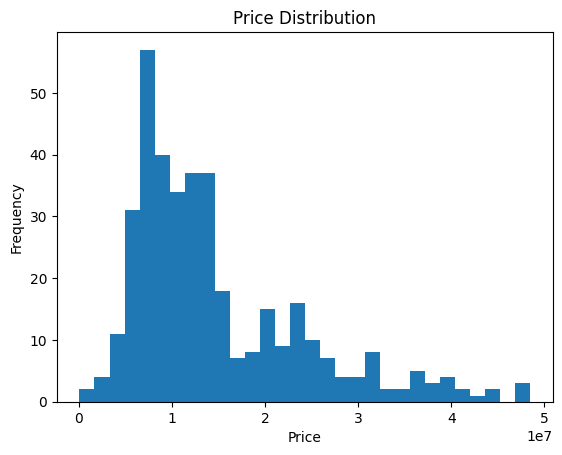

In [22]:
# Basic EDA 

# Price distribution
import matplotlib.pyplot as plt

plt.hist(df["Price"], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

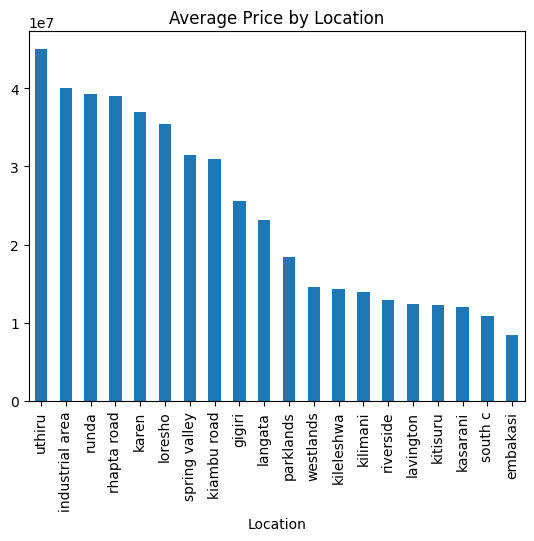

In [23]:
# Average price by location
df.groupby("Location")["Price"].mean().sort_values(ascending=False).head(20).plot(kind="bar")
plt.title("Average Price by Location")
plt.show()

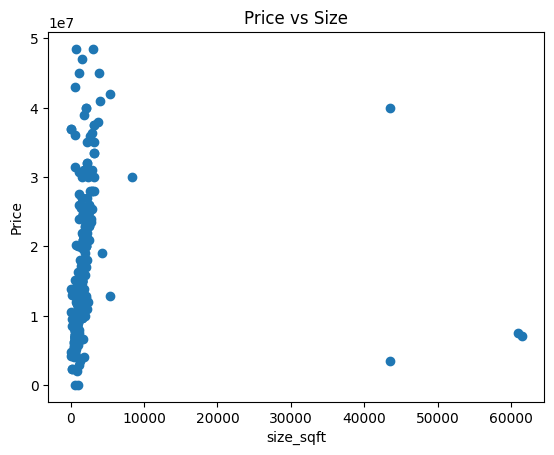

In [24]:
# Price vs Size
plt.scatter(df["size_sqft"], df["Price"])
plt.xlabel("size_sqft")
plt.ylabel("Price")
plt.title("Price vs Size")
plt.show()

- from the graph above i noticed there was some outliers . I Checked for the correlation 

In [25]:
df["Price"].corr(df["size_sqft"])

np.float64(0.08425081687011418)

##### How strongly does size affect price?

- There is a very  weak positive correlation. I Remove extreme size outliers

In [26]:
df_clean = df[df["size_sqft"] < df["size_sqft"].quantile(0.99)]

df_clean["Price"].corr(df_clean["size_sqft"])

np.float64(0.6340890637410272)

<Axes: xlabel='size_sqft', ylabel='Price'>

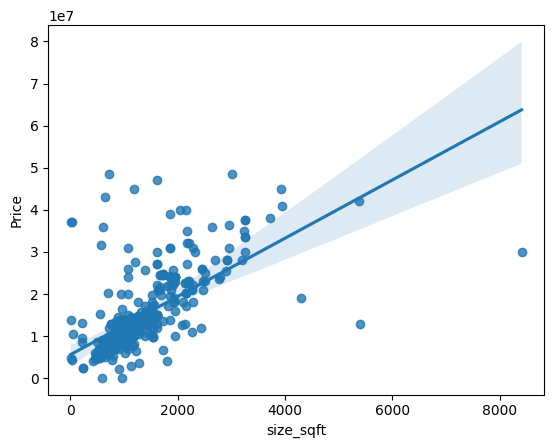

In [27]:
import seaborn as sns
sns.regplot(data=df_clean, x="size_sqft", y="Price")

- After removing extreme size outliers, the correlation between property size and price increased from 0.09 to 0.66, indicating a strong positive relationship. This confirms that property size is a significant determinant of price in the Nairobi housing market datase

In [28]:
# Which location is the most expensive
df.groupby("Location")["Price"].mean().sort_values(ascending=False).head(20)


Location
uthiru             4.500000e+07
industrial area    4.000000e+07
runda              3.925000e+07
rhapta road        3.900000e+07
karen              3.700000e+07
loresho            3.540000e+07
spring valley      3.150000e+07
kiambu road        3.100000e+07
gigiri             2.560000e+07
langata            2.320000e+07
parklands          1.845000e+07
westlands          1.454641e+07
kileleshwa         1.427068e+07
kilimani           1.400966e+07
riverside          1.294643e+07
lavington          1.246875e+07
kitisuru           1.225000e+07
kasarani           1.200000e+07
south c            1.090000e+07
embakasi           8.500000e+06
Name: Price, dtype: float64

- From the above we note that  houses located in uthiru are the most expensive 


In [29]:
df_clean.groupby("Amenities_count")["Price"].median()

Amenities_count
1     12000000.0
2     11500000.0
3     11850000.0
4      7800000.0
5      9950000.0
6     11000000.0
7     32000000.0
8      8550000.0
9      8500000.0
10    12850000.0
11    12910000.0
12     8000000.0
13    10550000.0
14    10175000.0
15    21000000.0
16    14700000.0
17    13050000.0
18    22600000.0
19     6820000.0
20     9350000.0
21    12500000.0
22    16380000.0
23    11075000.0
25    24400000.0
28    32000000.0
33    11750000.0
36    17000000.0
37     9880000.0
49    10000000.0
56     8800000.0
Name: Price, dtype: float64

In [30]:
df

,Title,Location,Bedrooms,Bathrooms,House Size,Price,Property Type,Listing Date,Amenities,size_value,size_unit,size_sqft,Price_per_sqft,Amenities_count,Listing Month,Listing Month Name,Listing Year,distance_to_cbd_km
0,3 Bedroom Apartment / Flat,westlands,3.0,4.5,155 m²,24600000,Apartment / Flat,2026-02-20,"400 m fully equipped gym, 17acre shopping mall...",155.0,m²,1668.40,14744.67,11,2,February,2026,5.654415
1,1 Bedroom Apartment / Flat,westlands,1.0,1.0,65 m²,6500000,Apartment / Flat,2026-02-18,none,65.0,m²,699.65,9290.36,1,2,February,2026,5.654415
2,2 Bedroom Apartment / Flat,kilimani,2.0,2.0,110 m²,11800000,Apartment / Flat,2026-02-16,plumeria residency is located at the intersect...,110.0,m²,1184.03,9965.96,12,2,February,2026,4.936608
3,2 Bedroom Apartment / Flat,riverside,2.0,2.0,114 m²,13600000,Apartment / Flat,2026-02-16,"1 bedroom 6081 from ksh 72m to 1092m, 2 bedro...",114.0,m²,1227.08,11083.22,17,2,February,2026,5.982157
4,3 Bedroom Apartment / Flat,westlands,3.0,3.0,155 m²,21714000,Apartment / Flat,2026-02-16,none,155.0,m²,1668.40,13014.86,1,2,February,2026,5.654415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,2 Bedroom Apartment / Flat,kilimani,2.0,2.0,120 m²,10500000,Apartment / Flat,2026-02-09,"yaya centre 5 mins, adams arcade 6 mins, pre...",120.0,m²,1291.67,8129.01,15,2,February,2026,4.936608
445,1 Bedroom Apartment / Flat,westlands,1.0,1.0,46 m²,8500000,Apartment / Flat,2025-11-09,"rooftop swimming pool, fully equipped rooftop ...",46.0,m²,495.14,17166.86,9,11,November,2025,5.654415
447,4 Bedroom Apartment / Flat,westlands,4.0,5.0,172 m²,31000000,Apartment / Flat,2025-11-10,none,172.0,m²,1851.39,16744.18,1,11,November,2025,5.654415
448,1 Bedroom Apartment / Flat,westlands,1.0,1.0,4 m²,4200000,Apartment / Flat,2026-02-06,"perfect for families, executives investors",4.0,m²,43.06,97538.32,2,2,February,2026,5.654415


In [31]:
# create a new csv file with the cleaned data
df.to_csv("kenya_property24_sales_cleaned.csv", index=False)